In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pk


In [ ]:
df = pd.read_csv("/content/data_processed.csv")
with open("/content/robust_scaler.pkl", "rb") as f:
    loaded_scaler = pk.load(f)
df.head()

,price,sqft_living,sqft_lot,waterfront,sqft_above,sqft_basement,street,city,year,month,...,floors,view,condition,yr_built,yr_renovated,log_price,log_sqft_living,log_sqft_lot,log_sqft_above,log_sqft_basement
0,313000.0,1340,7912,0,1340,0,18810 Densmore Ave N,Shoreline,2014,5,...,0.0,0.0,0.0,-0.456522,1.003002,-0.547243,-0.667630,0.037253,-0.259581,0.000000
1,2384000.0,3650,9050,0,3370,280,709 W Blaine St,Seattle,2014,5,...,0.5,4.0,2.0,-1.195652,0.000000,2.323245,1.046138,0.207703,1.140150,0.878920
2,342000.0,1930,11947,0,1930,0,26206-26214 143rd Ave SE,Kent,2014,5,...,-0.5,0.0,1.0,-0.217391,0.000000,-0.421970,-0.043741,0.559961,0.294093,0.000000
3,420000.0,2000,8030,0,1000,1000,857 170th Pl NE,Bellevue,2014,5,...,-0.5,0.0,1.0,-0.282609,0.000000,-0.131513,0.017188,0.056030,-0.703611,1.076953
4,550000.0,1940,10500,0,1140,800,9105 170th Ave NE,Redmond,2014,5,...,-0.5,0.0,1.0,0.000000,0.996498,0.249738,-0.034903,0.396201,-0.504832,1.042207


In [ ]:
print(df.columns)

Index(['price', 'sqft_living', 'sqft_lot', 'waterfront', 'sqft_above',
       'sqft_basement', 'street', 'city', 'year', 'month', 'day', 'zipcode',
       'city_clean', 'city_encoded', 'bedrooms', 'bathrooms', 'floors', 'view',
       'condition', 'yr_built', 'yr_renovated', 'log_price', 'log_sqft_living',
       'log_sqft_lot', 'log_sqft_above', 'log_sqft_basement'],
      dtype='object')


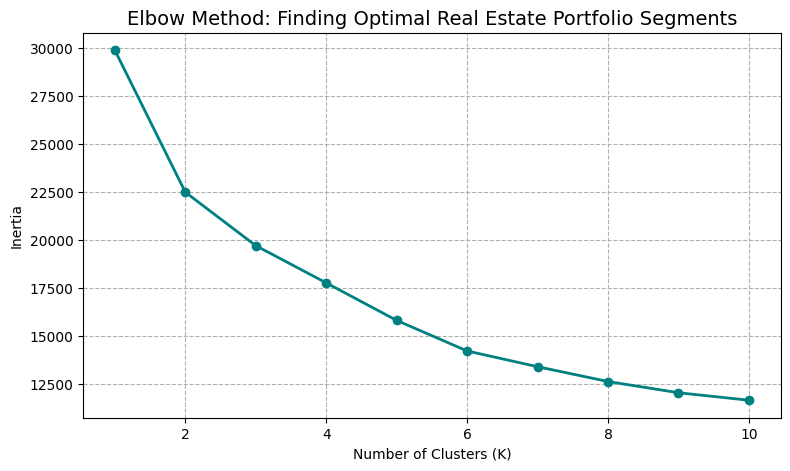

In [ ]:
clustering_features_list = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'log_sqft_basement',
    'bedrooms', 'bathrooms', 'floors', 'view', 'condition',
    'yr_built', 'yr_renovated', 'waterfront'
]
X_train = df[clustering_features_list].copy()
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', linewidth=2, color='teal')
plt.title('Elbow Method: Finding Optimal Real Estate Portfolio Segments', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--')
plt.show()

In [ ]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=15, init='k-means++')
df['cluster_id'] = kmeans_final.fit_predict(X_train)
print(df['cluster_id'].value_counts())

cluster_id
0    2006
2    1702
1     892
Name: count, dtype: int64


In [ ]:
profile_cols = [
    'price', 'bedrooms', 'bathrooms', 'floors', 'view', 'condition',
    'sqft_living', 'sqft_lot', 'yr_built', 'cluster_id'
]

cluster_summary = df[profile_cols].groupby('cluster_id').mean().round(2)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(cluster_summary)

                price  bedrooms  bathrooms  floors  view  condition  sqft_living  sqft_lot  yr_built
cluster_id                                                                                          
0           421785.32     -0.08      -0.99   -0.35  0.13       0.63      1497.86   9090.29     -0.52
1           854599.46      1.11       0.82    0.14  0.83       0.48      3284.73  44330.89      0.04
2           546783.59      0.60       0.42    0.38  0.07       0.23      2295.13   6194.65      0.29


In [ ]:
from google.colab import files
df.to_csv('/content/data_clustered.csv', index=True)
files.download('data_clustered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>